In [109]:
# Verify library versions
import tdt
import neurokit2 as nk
from neurokit2 import signal_filter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import signal_processing as sp
import importlib

print("TDT version:", tdt.__version__)
print("NeuroKit2 version:", nk.__version__)
print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)
print("Matplotlib version:", matplotlib.__version__)

TDT version: 0.6.6
NeuroKit2 version: 0.2.10
NumPy version: 1.26.4
Pandas version: 2.2.3
Matplotlib version: 3.10.0


### Replace these paths with the ones on your local computer

In [110]:
# b stands for bully, c for cagemate

subj_11_b_path = r'C:\Users\tomhu\Desktop\Code\respiratory_pilot\Data\sub_11_12\copies\subj11-bully\subj11-250227-071832'
subj_11_c_path = r'C:\Users\tomhu\Desktop\Code\respiratory_pilot\Data\sub_11_12\copies\subj11-cagemate\subj11-250227-071133'
subj_12_b_path = r'C:\Users\tomhu\Desktop\Code\respiratory_pilot\Data\sub_11_12\copies\subj12-bully'
subj_12_c_path = r'C:\Users\tomhu\Desktop\Code\respiratory_pilot\Data\sub_11_12\copies\subj12-cagemate\subj12-250227-111411'

subj_11_b = tdt.read_block(subj_11_b_path)
subj_11_c = tdt.read_block(subj_11_c_path)
subj_12_b = tdt.read_block(subj_12_b_path)
subj_12_c = tdt.read_block(subj_12_c_path)

print(subj_11_b)
# print(subj_11_c)
# print(subj_12_b)
# print(subj_12_c)


Found Synapse note file: C:\Users\tomhu\Desktop\Code\respiratory_pilot\Data\sub_11_12\copies\subj11-bully\subj11-250227-071832\Notes.txt
read from t=0s to t=343.94s
Found Synapse note file: C:\Users\tomhu\Desktop\Code\respiratory_pilot\Data\sub_11_12\copies\subj11-cagemate\subj11-250227-071133\Notes.txt
read from t=0s to t=308.64s
Found Synapse note file: C:\Users\tomhu\Desktop\Code\respiratory_pilot\Data\sub_11_12\copies\subj12-cagemate\subj12-250227-111411\Notes.txt
read from t=0s to t=309.94s
epocs	[struct]
snips	[struct]
streams	[struct]
scalars	[struct]
info	[struct]
time_ranges:	array([[ 0.],
       [inf]])


C:\Users\tomhu\AppData\Local\Temp\ipykernel_42228\2541156112.py:10: Warning: no tsq file found, attempting to read sev files
  subj_12_b = tdt.read_block(subj_12_b_path)


### Extracting attributes for subj_11_bully

In [111]:
subj_11_b_resp_stream = subj_11_b.streams['Resp']

subj_11_b_resp_data = subj_11_b_resp_stream.data
subj_11_b_resp_size = subj_11_b_resp_data.shape[0]

subj_11_b_resp_fs = subj_11_b_resp_stream.fs
subj_11_b_resp_start_time = subj_11_b_resp_stream.start_time
subj_11_b_resp_data_shape = subj_11_b_resp_stream.data.shape
subj_11_b_resp_size = subj_11_b_resp_data.shape[0]
subj_11_b_resp_channel = subj_11_b_resp_stream.channel
subj_11_b_resp_stream_name = subj_11_b_resp_stream.name



### Finding duration of data in seconds and minutes

In [112]:
print(f"Sampling frequency (fs): {subj_11_b_resp_fs} Hz")
print(f"Size: {subj_11_b_resp_size}")

# Compute total duration in seconds
total_duration = subj_11_b_resp_size / subj_11_b_resp_fs  

# Convert to minutes
total_duration_minutes = total_duration / 60  

print(f"Total duration of respiratory data: {total_duration} seconds ({total_duration_minutes} minutes)")

Sampling frequency (fs): 305.17578125 Hz
Size: 104960
Total duration of respiratory data: 343.932928 seconds (5.732215466666667 minutes)


### Filtering respiratory data

In [113]:
# Apply the custom filtering logic
subj_11_b_rsp_cleaned = nk.signal_filter(
    subj_11_b_resp_data,  # Input signal
    lowcut=0.1,   # Low cutoff frequency (Hz)
    highcut=20,   # High cutoff frequency (Hz)
    method="butterworth",  # Filtering method
    sampling_rate=subj_11_b_resp_fs,  # Sampling rate
    order=2  # Filter order
)

### Resiratory Data Array

In [114]:
subj_11_b_rsp_cleaned

array([-0.0031903 , -0.00290879, -0.00253945, ..., -0.1844463 ,
       -0.17164294, -0.15903175])

### Plotting entire cleaned subj11 bully resp signal

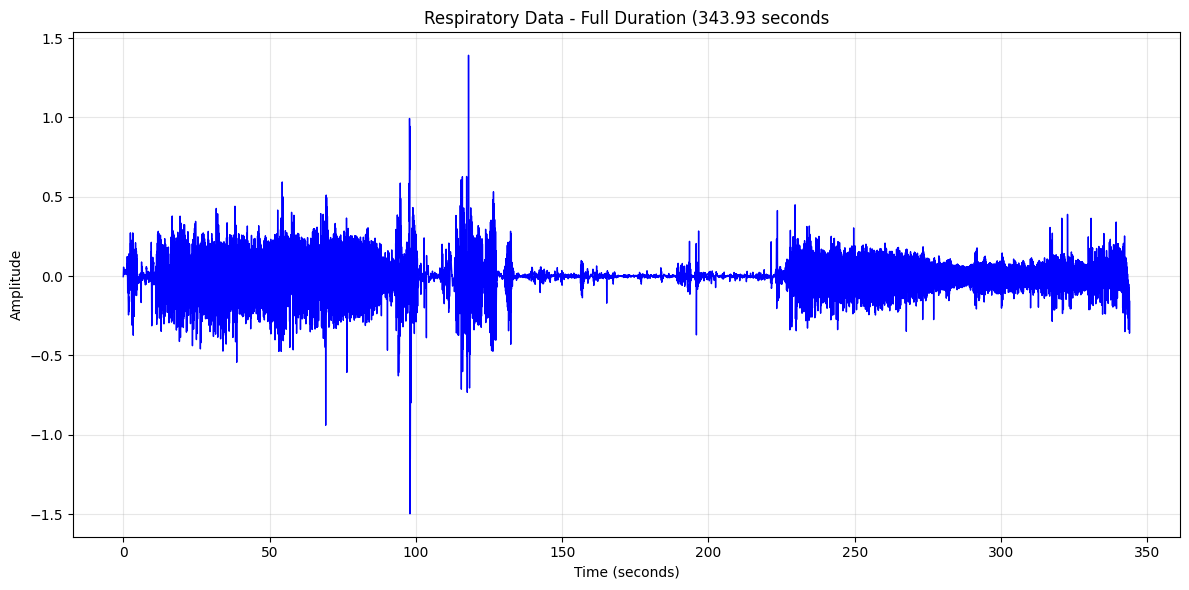

In [115]:
n_samples = len(subj_11_b_rsp_cleaned)

# Create time array for x-axis
time = np.arange(n_samples) / subj_11_b_resp_fs + subj_11_b_resp_start_time

# Create the plot
plt.figure(figsize=(12, 6))
plt.plot(time, subj_11_b_rsp_cleaned, 'b-', linewidth=1) 

# Add labels and title
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')
plt.title(f'Respiratory Data - Full Duration ({n_samples/subj_11_b_resp_fs:.2f} seconds')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

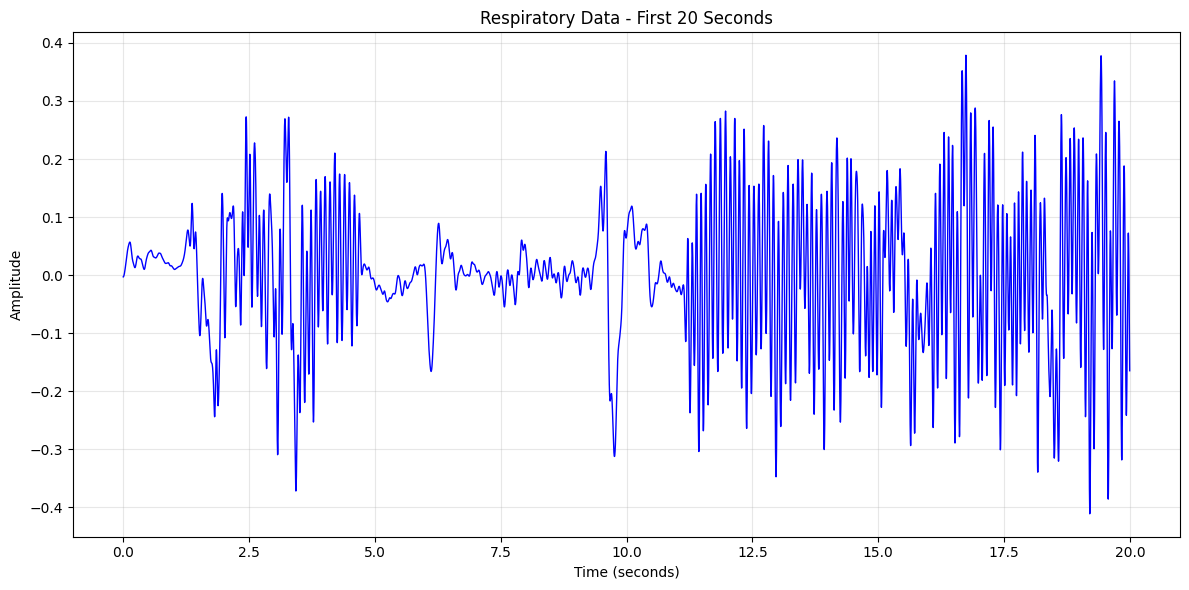

In [116]:
n_samples = int(20 * subj_11_b_resp_fs)  # Number of samples for 10 seconds

# Create time array for x-axis
time = np.arange(n_samples) / subj_11_b_resp_fs + subj_11_b_resp_start_time

# Create the plot
plt.figure(figsize=(12, 6))
plt.plot(time, subj_11_b_rsp_cleaned[:n_samples], 'b-', linewidth=1)

# Add labels and title
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')
plt.title(f'Respiratory Data - First {20} Seconds')

# Add grid for better readability
plt.grid(True, alpha=0.3)

# Adjust layout to prevent label cutoff
plt.tight_layout()

In [117]:
print(subj_11_b_resp_start_time)

0.0


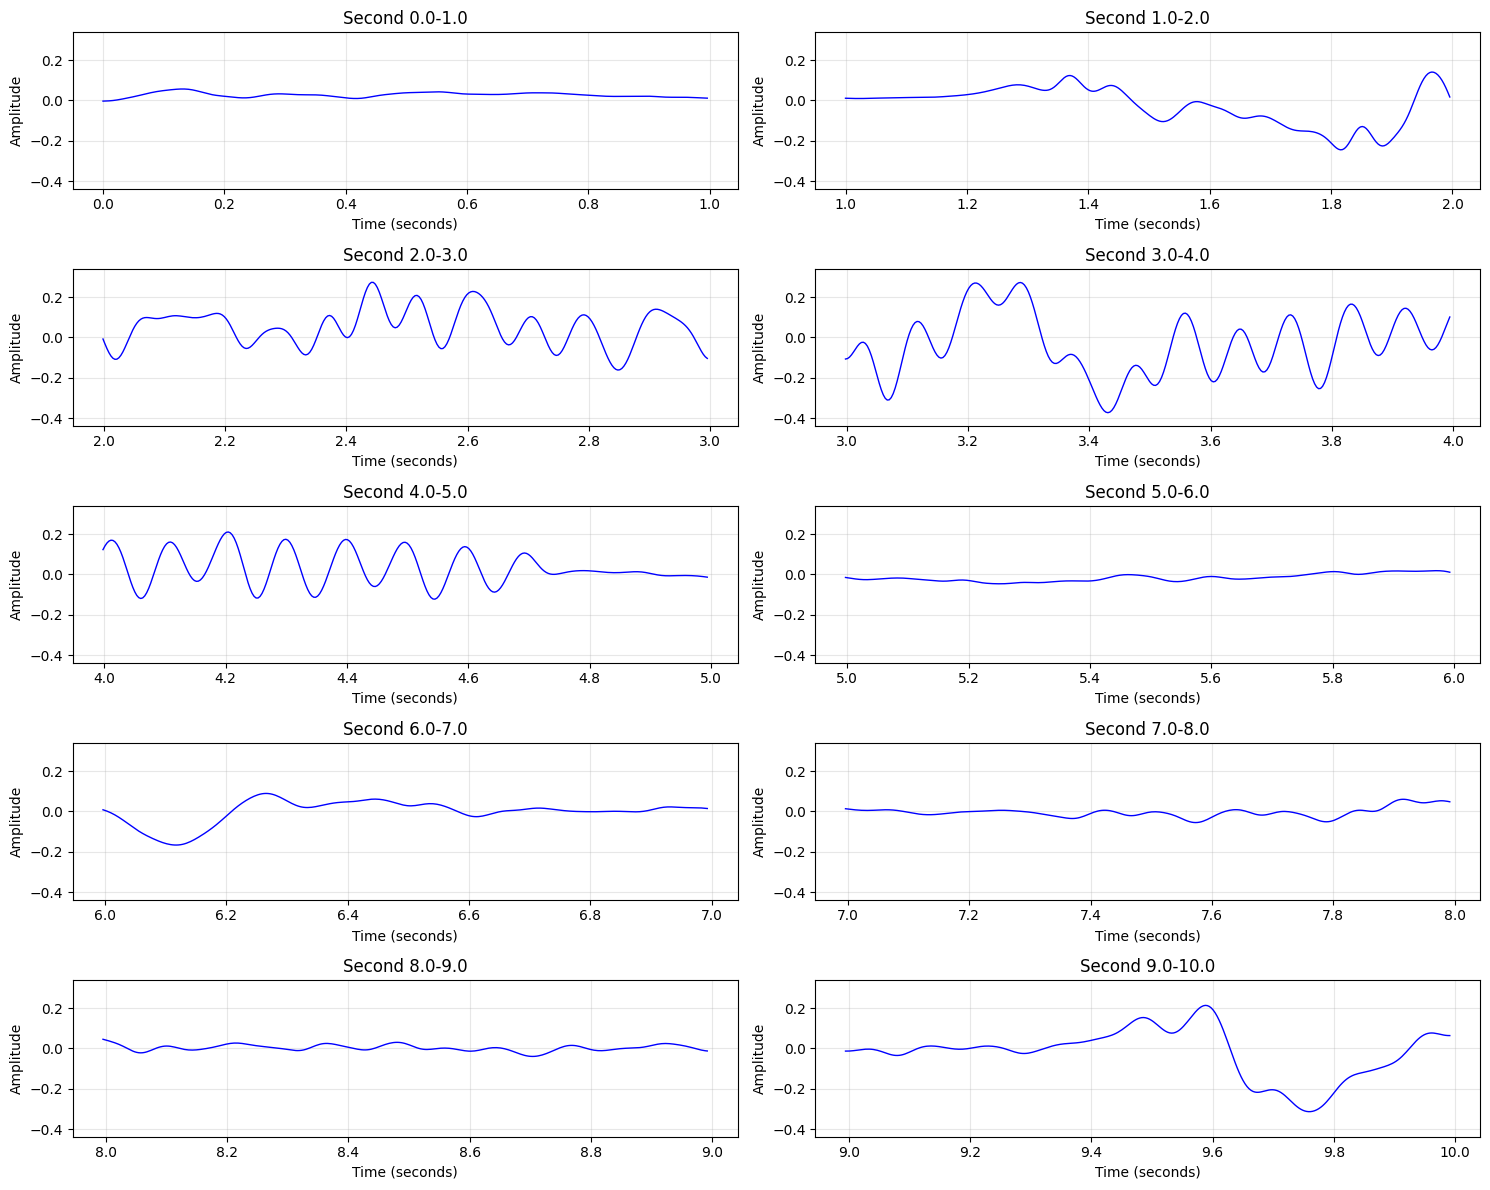

In [118]:
import resp_plotting
import importlib
importlib.reload(resp_plotting)

resp_plotting.plot_respiratory_data_by_second(subj_11_b_rsp_cleaned, subj_11_b_resp_fs, subj_11_b_resp_start_time)

### Anogential sniffing 10.605-14.355

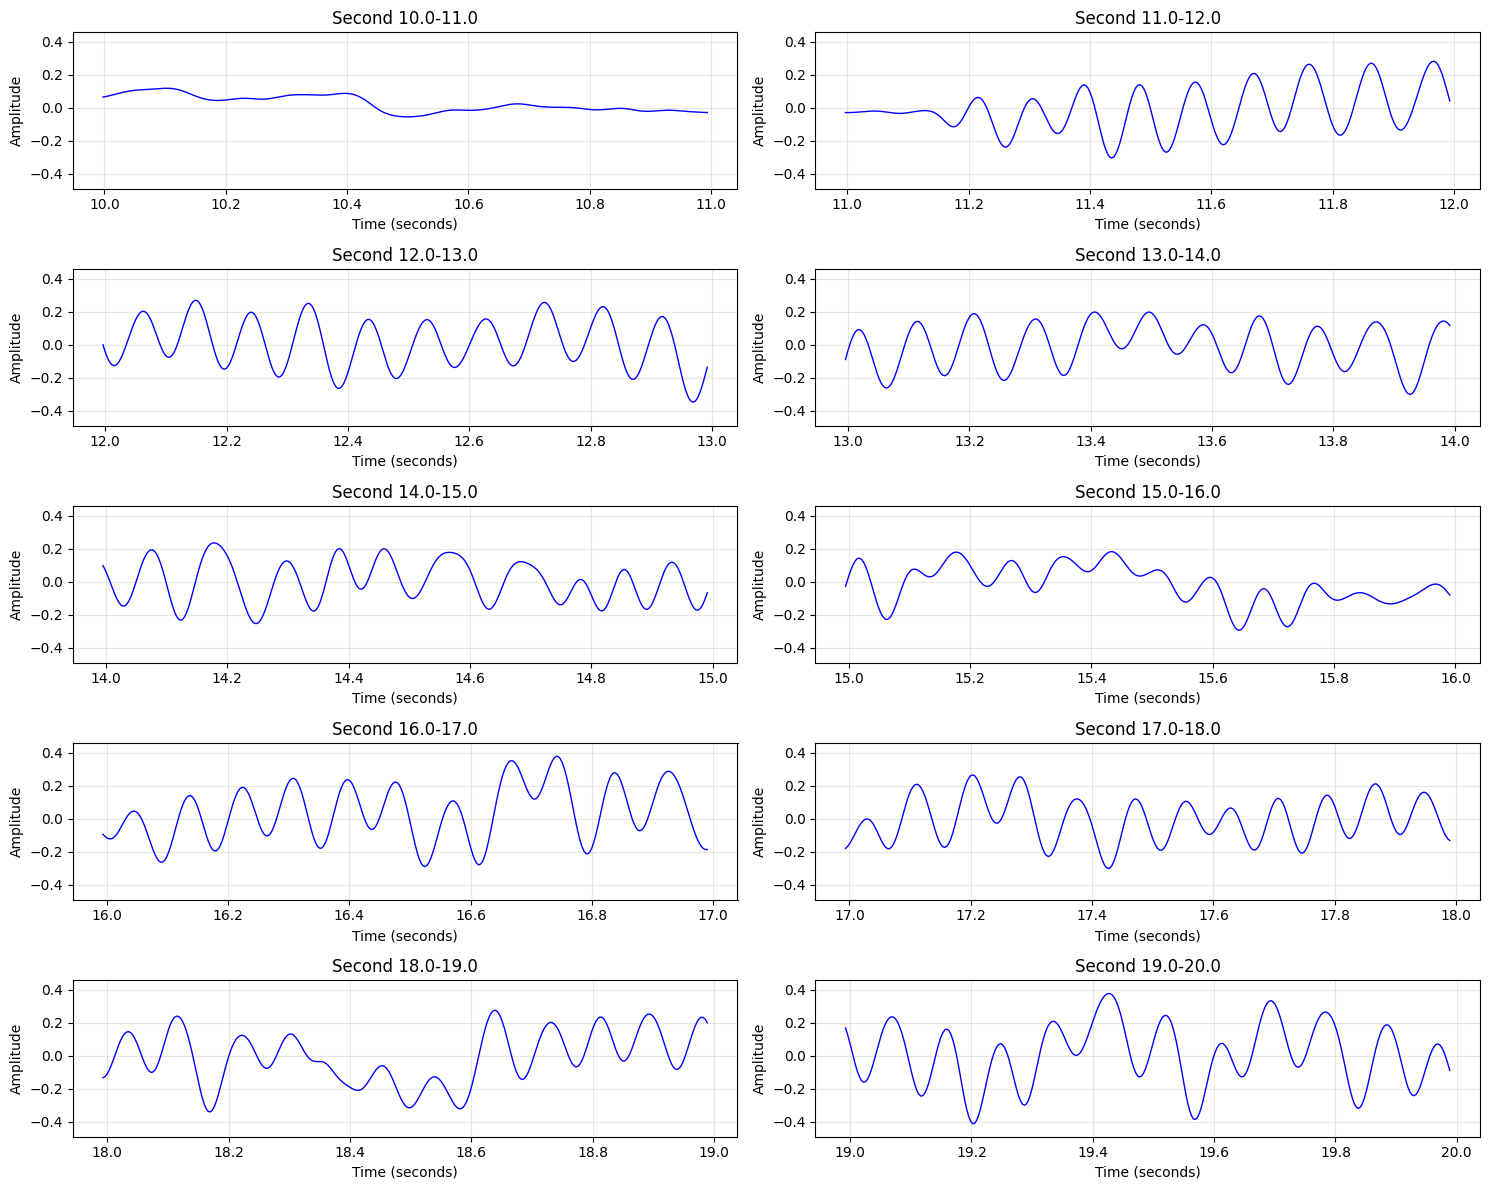

In [119]:
resp_plotting.plot_respiratory_data_by_second(subj_11_b_rsp_cleaned, subj_11_b_resp_fs, subj_11_b_resp_start_time+10)

### Allogrooming 28.905-31.603

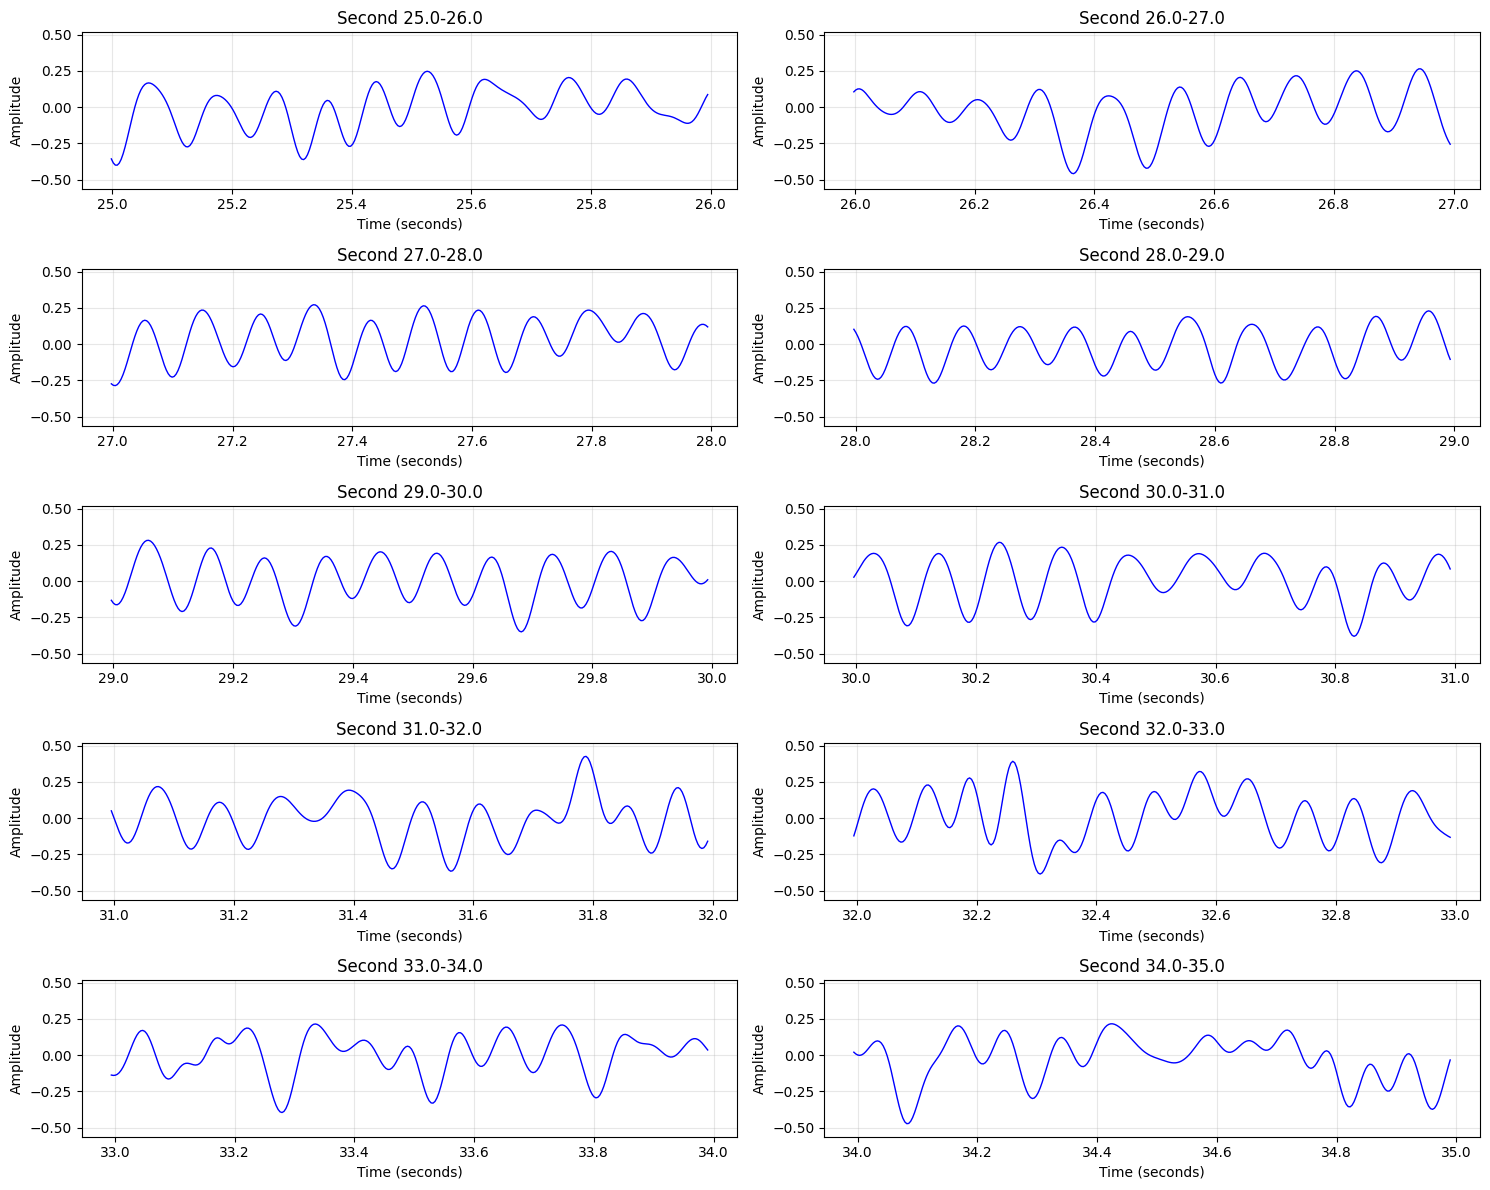

In [120]:
resp_plotting.plot_respiratory_data_by_second(subj_11_b_rsp_cleaned, subj_11_b_resp_fs, subj_11_b_resp_start_time+25)

### Fighting 31.63-35.425 and Fighting 37.28-41.23

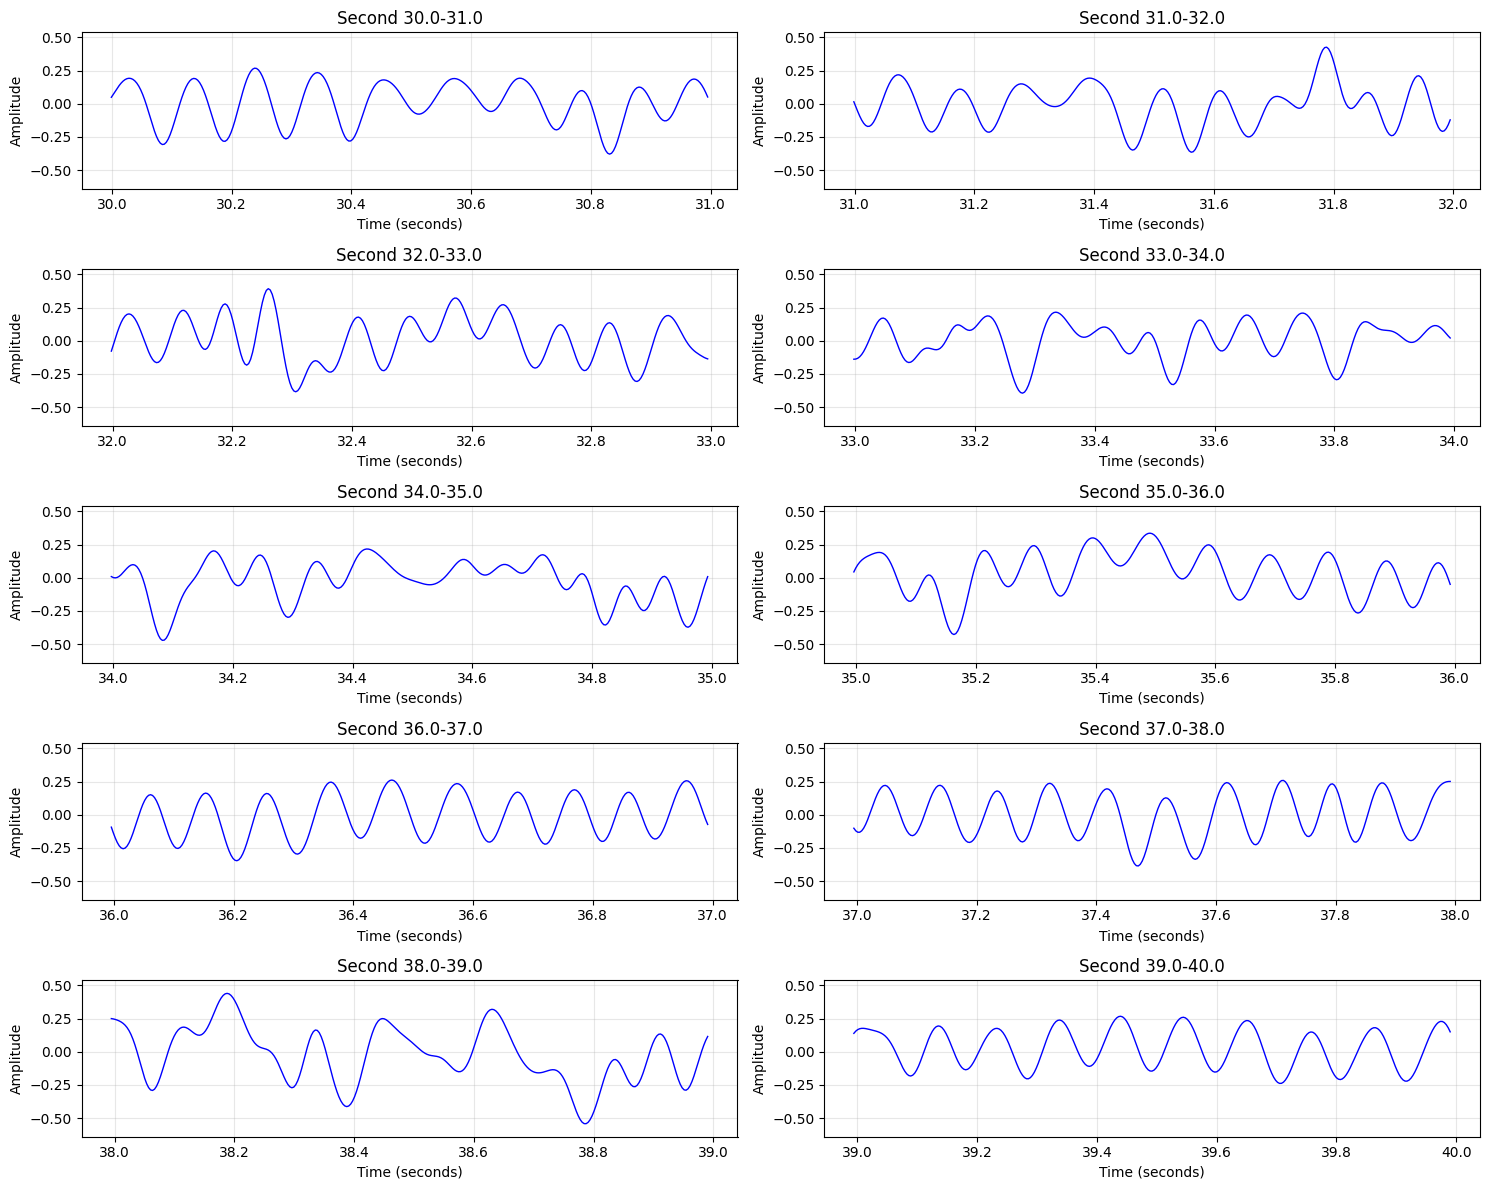

In [121]:
resp_plotting.plot_respiratory_data_by_second(subj_11_b_rsp_cleaned, subj_11_b_resp_fs, subj_11_b_resp_start_time+30)

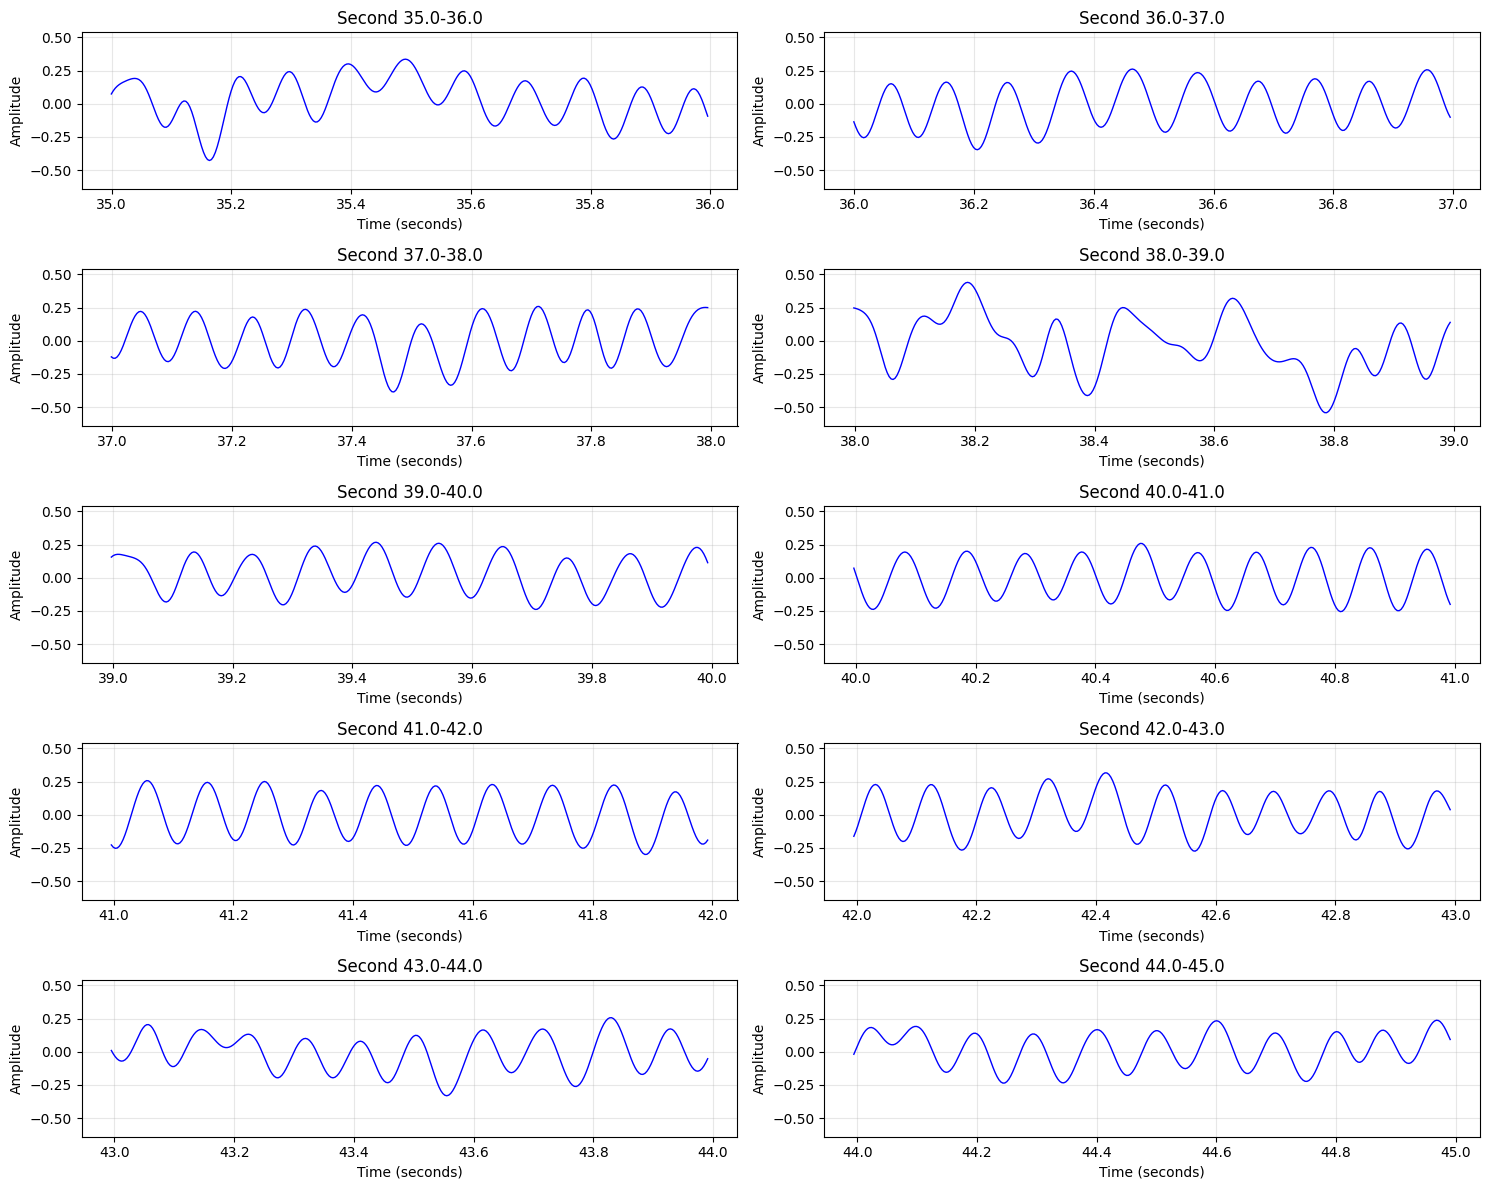

In [122]:
resp_plotting.plot_respiratory_data_by_second(subj_11_b_rsp_cleaned, subj_11_b_resp_fs, subj_11_b_resp_start_time+35)

### Creating dataframe for resp signal and boris data

In [123]:
# Generate timestamps
timestamps = np.arange(0, total_duration, 1/subj_11_b_resp_fs)  # Create time axis

# Create the respiration dataframe
resp_df = pd.DataFrame({
    "Timestamp (s)": timestamps,
    "Respiration Value": subj_11_b_rsp_cleaned,
    "Behavioral Event": np.nan  # To be filled later from BORIS mapping
})


resp_df.head()

,Timestamp (s),Respiration Value,Behavioral Event
0,0.000000,-0.003190,NaN
1,0.003277,-0.002909,NaN
2,0.006554,-0.002539,NaN
3,0.009830,-0.002005,NaN
4,0.013107,-0.001252,NaN


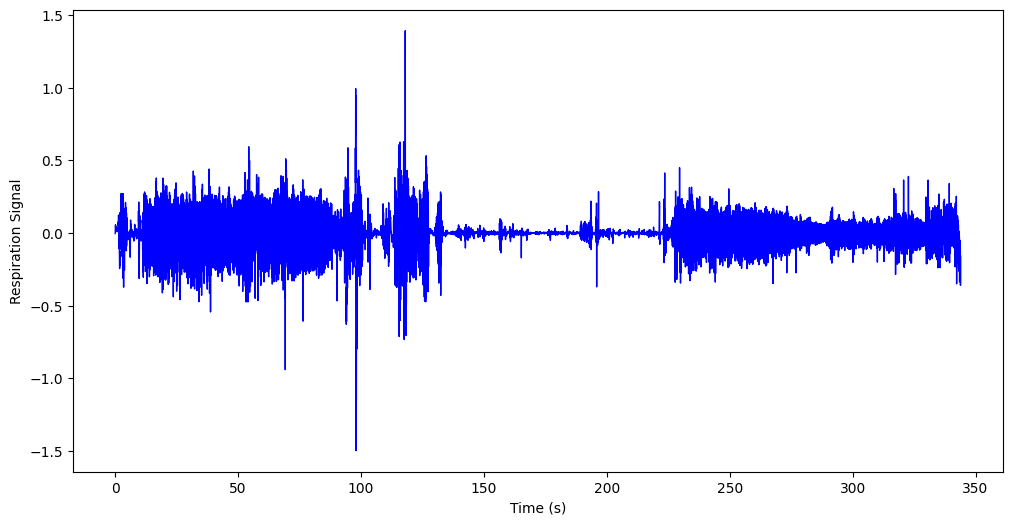

In [124]:
# Plot data
plt.figure(figsize=(12, 6))
plt.plot(resp_df["Timestamp (s)"], resp_df["Respiration Value"], 'b-', linewidth=1)
plt.xlabel("Time (s)")
plt.ylabel("Respiration Signal")
plt.show()

In [125]:
boris_path = r'C:\Users\tomhu\Desktop\Code\respiratory_pilot\BorisData\sequioaBoris\subject_11_bully_AE.csv'

boris_data = pd.read_csv(boris_path)
boris_data.head()

,Observation id,Observation date,Description,Media file,Total length,FPS,Subject,Behavior,Behavioral category,Modifiers,Behavior type,Start (s),Stop (s),Duration (s),Comment start,Comment stop
0,subj_11_bully,2025-03-02 18:45:24,NaN,/Users/ayushjain/Downloads/nasal_test-241015-0...,343.9,10.0,subject,anogenital sniffing,NaN,NaN,STATE,10.605,14.355,3.750,NaN,NaN
1,subj_11_bully,2025-03-02 18:45:24,NaN,/Users/ayushjain/Downloads/nasal_test-241015-0...,343.9,10.0,subject,allogrooming,NaN,NaN,STATE,28.905,31.603,2.698,NaN,NaN
2,subj_11_bully,2025-03-02 18:45:24,NaN,/Users/ayushjain/Downloads/nasal_test-241015-0...,343.9,10.0,subject,fighting,NaN,NaN,STATE,31.630,35.425,3.795,NaN,NaN
3,subj_11_bully,2025-03-02 18:45:24,NaN,/Users/ayushjain/Downloads/nasal_test-241015-0...,343.9,10.0,subject,fighting,NaN,NaN,STATE,37.280,41.230,3.950,NaN,NaN
4,subj_11_bully,2025-03-02 18:45:24,NaN,/Users/ayushjain/Downloads/nasal_test-241015-0...,343.9,10.0,subject,fighting,NaN,NaN,STATE,55.955,60.355,4.400,NaN,NaN


In [126]:
boris_data = boris_data[['Behavior', 'Start (s)', 'Stop (s)']]
boris_data.head()

,Behavior,Start (s),Stop (s)
0,anogenital sniffing,10.605,14.355
1,allogrooming,28.905,31.603
2,fighting,31.630,35.425
3,fighting,37.280,41.230
4,fighting,55.955,60.355


In [127]:
# Iterate over BORIS events and map behaviors onto respiration timestamps
for _, row in boris_data.iterrows():
    start_time = row["Start (s)"]
    stop_time = row["Stop (s)"]
    behavior = row["Behavior"]

    # Mask: Find respiration timestamps that fall within the behavior window
    mask = (resp_df["Timestamp (s)"] >= start_time) & (resp_df["Timestamp (s)"] <= stop_time)

    # Assign the behavior to matching respiration timestamps
    resp_df.loc[mask, "Behavioral Event"] = behavior

# Reset start_time
start_time = 0

C:\Users\tomhu\AppData\Local\Temp\ipykernel_42228\3689120803.py:11: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'anogenital sniffing' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  resp_df.loc[mask, "Behavioral Event"] = behavior


In [128]:
# Around when behavior first starts
resp_df[(resp_df["Timestamp (s)"] >= 11)].head(10)

,Timestamp (s),Respiration Value,Behavioral Event
3357,11.000218,-0.028742,anogenital sniffing
3358,11.003494,-0.028640,anogenital sniffing
3359,11.006771,-0.028345,anogenital sniffing
3360,11.010048,-0.027855,anogenital sniffing
3361,11.013325,-0.027182,anogenital sniffing
3362,11.016602,-0.026349,anogenital sniffing
3363,11.019878,-0.025389,anogenital sniffing
3364,11.023155,-0.024347,anogenital sniffing
3365,11.026432,-0.023272,anogenital sniffing
3366,11.029709,-0.022220,anogenital sniffing


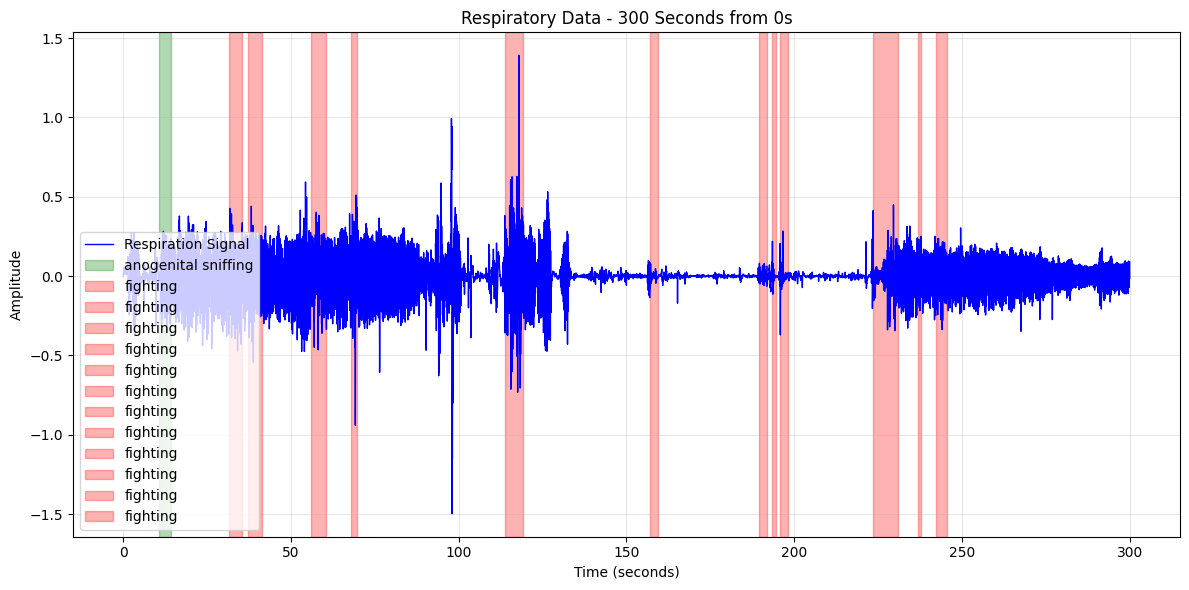

In [129]:
resp_plotting.resp_behavior_plot(resp_df, subj_11_b_resp_fs, start_time, duration=300)

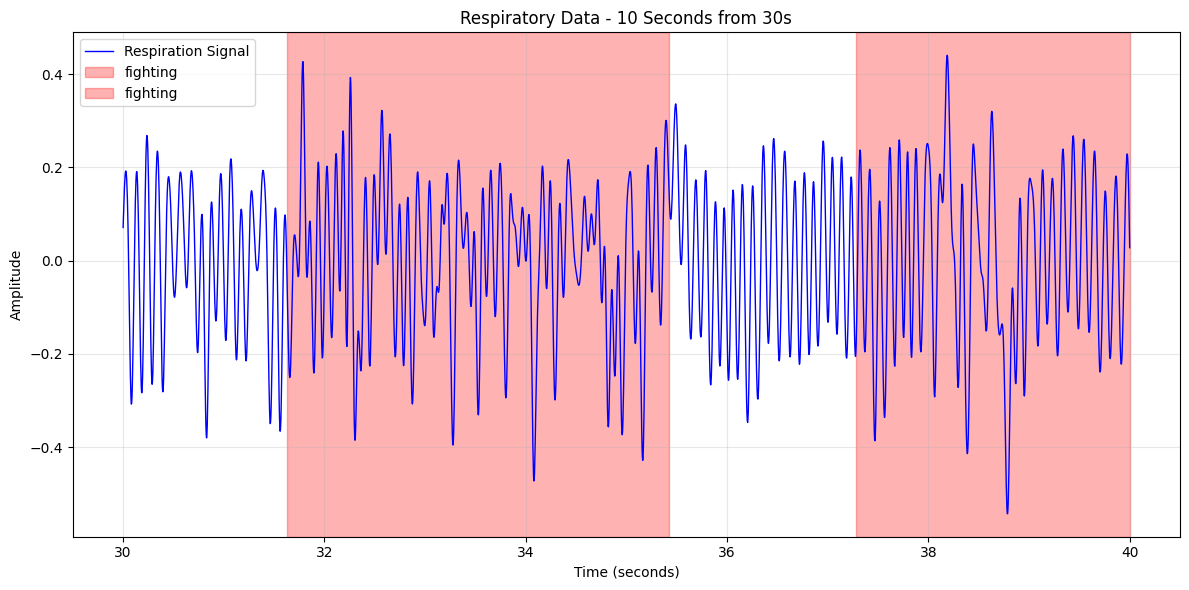

In [140]:
resp_plotting.resp_behavior_plot(resp_df, subj_11_b_resp_fs, start_time+30, duration=10)

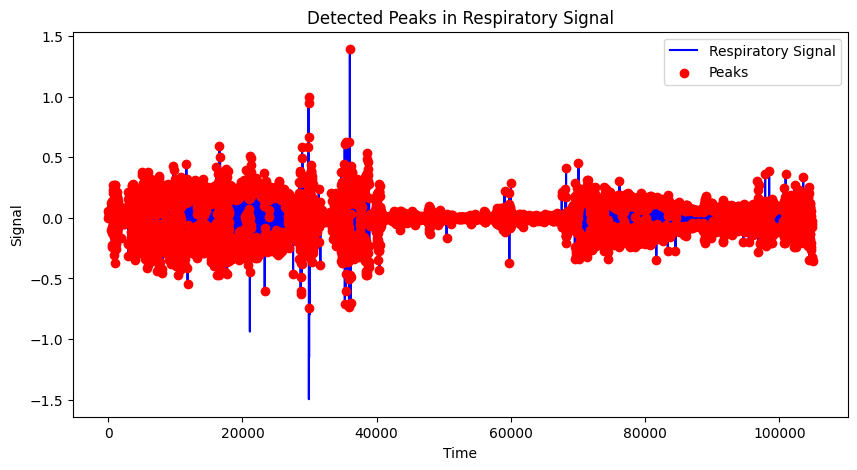

In [130]:
import signal_processing

peak_inds, peak_mags = signal_processing.peakfinder(resp_df['Respiration Value'])

# Create a new column in the DataFrame to mark detected peaks
resp_df['peak'] = 0
resp_df.loc[peak_inds.astype(int), 'peak'] = 1  # Mark peaks in the DataFrame

# Plot the signal with peaks
plt.figure(figsize=(10, 5))
plt.plot(resp_df.index, resp_df['Respiration Value'], label='Respiratory Signal', color='blue')
plt.scatter(resp_df.index[peak_inds.astype(int)], peak_mags, color='red', label='Peaks', zorder=3)
plt.xlabel('Time')
plt.ylabel('Signal')
plt.title('Detected Peaks in Respiratory Signal')
plt.legend()
plt.show()

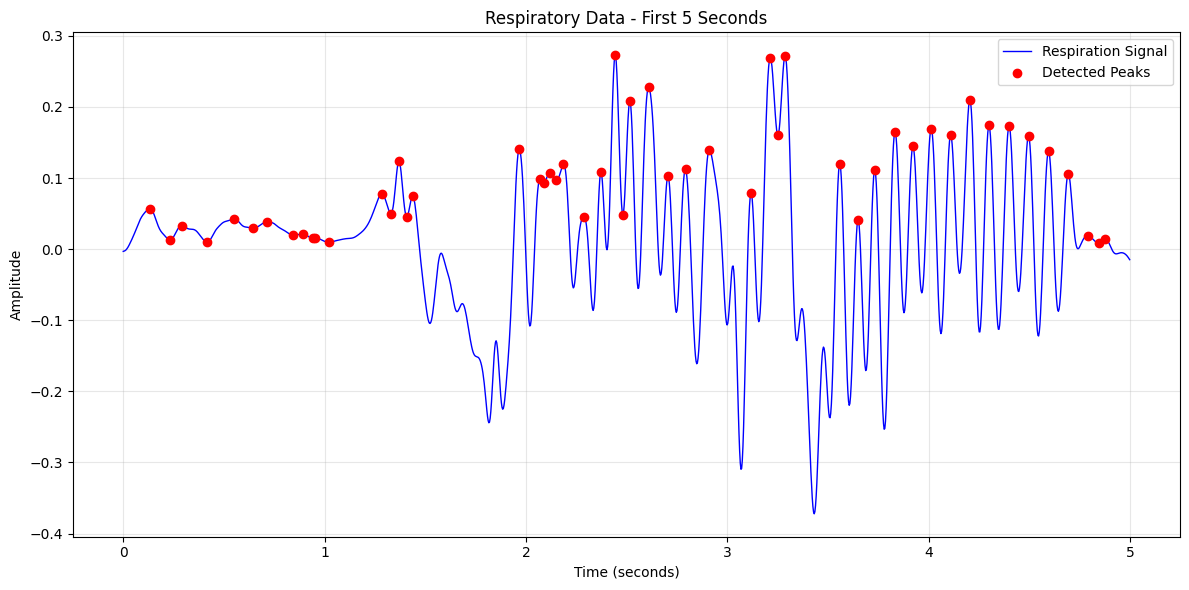

In [133]:
import importlib
importlib.reload(resp_plotting)

resp_plotting.final_resp_plot(resp_df, subj_11_b_resp_fs, start_time, duration=5, show_peaks=True, peak_sel=0.001, peak_thresh=0.003)

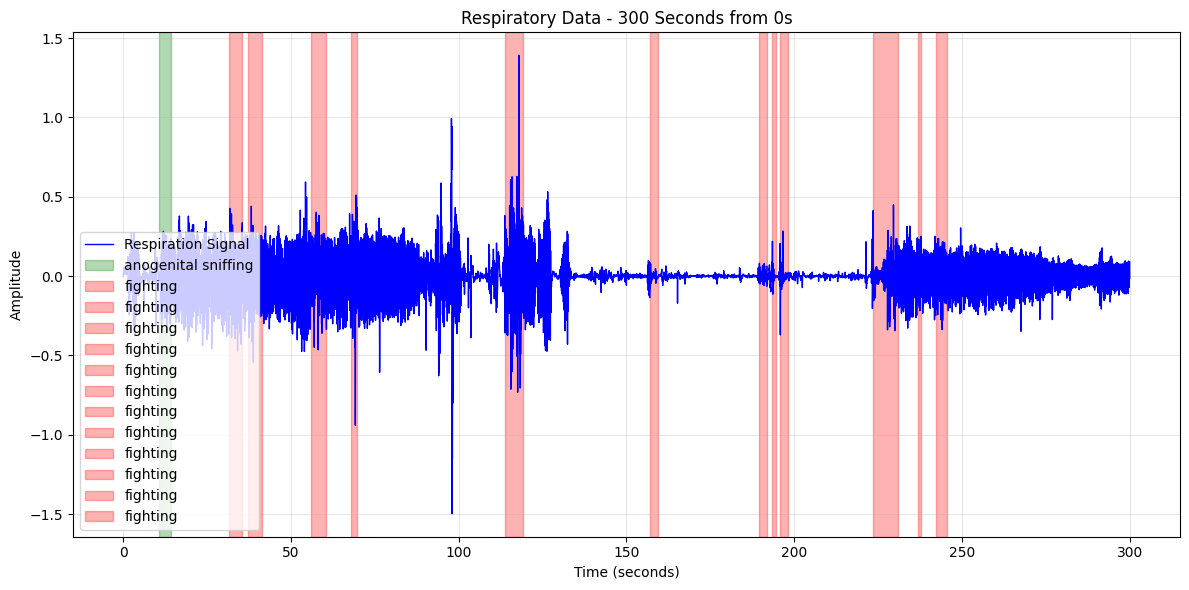

In [142]:
resp_plotting.resp_behavior_plot(resp_df, subj_11_b_resp_fs, start_time, duration=300)

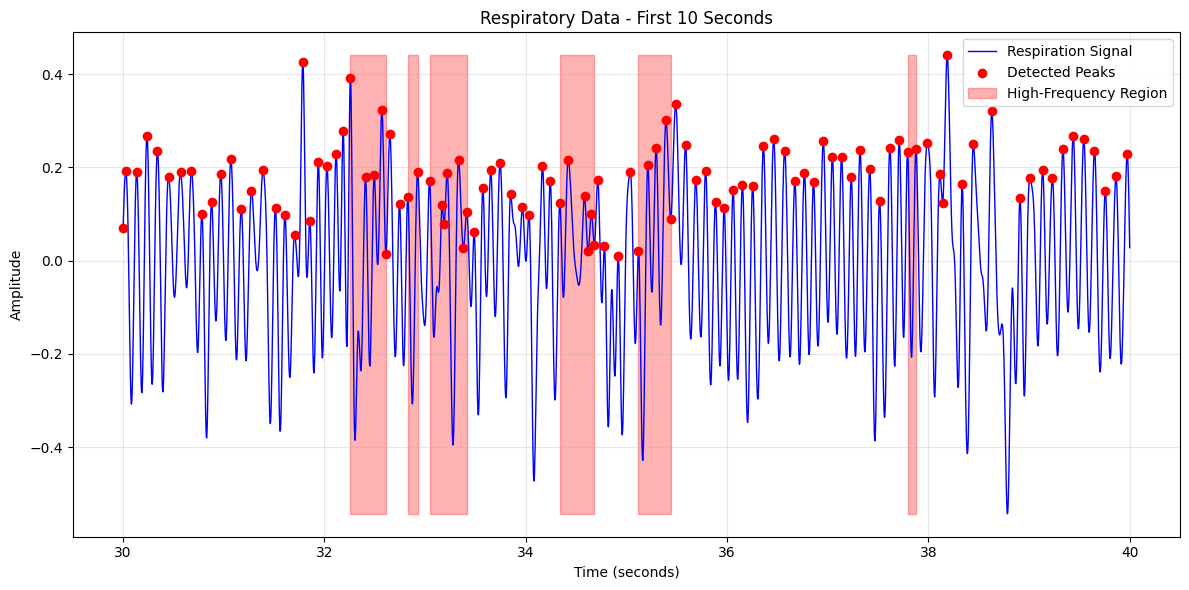

High-Frequency Regions (start, end): [(1.9660799999999998, 2.555904), (2.998272, 3.3685503999999997), (3.4308096, 3.6864), (3.7322751999999997, 3.964928), (4.6432256, 4.6923775999999995), (4.7415296, 4.7906816), (5.0823168, 5.2953088), (7.6382208, 7.864319999999999), (7.9167488, 7.9495168), (8.427929599999999, 8.5295104), (8.9980928, 9.0308608), (10.184294399999999, 10.2301696), (10.81344, 10.849484799999999), (10.89536, 10.928128), (11.0002176, 11.5245056), (11.9668736, 12.150374399999999), (13.3103616, 13.631488), (14.2475264, 14.385152), (14.630911999999999, 15.722086399999998), (15.967846399999999, 16.7411712), (16.8361984, 19.3724416), (19.428147199999998, 19.644416), (19.7394432, 20.1392128), (20.230963199999998, 20.627456), (20.6733312, 21.5580672), (21.6530944, 22.3674368), (22.7180544, 22.8950016), (22.9376, 23.2062976), (23.9140864, 24.00256), (24.051712, 24.49408), (25.1265024, 25.4410752), (27.2007168, 27.7020672), (28.18048, 28.3672576), (29.356851199999998, 29.44532479999

In [139]:
importlib.reload(signal_processing)
importlib.reload(resp_plotting)

high_freq_regions = signal_processing.find_high_frequency_regions(resp_df, subj_11_b_resp_fs, window_size=5,threshold_percentile=25)

resp_plotting.final_resp_plot2(resp_df, subj_11_b_resp_fs, start_time+30, duration=10, show_peaks=True, peak_sel=0.001, peak_thresh=0.003, show_high_freq_regions=True, high_freq_threshold_percentile=20)

print("High-Frequency Regions (start, end):", high_freq_regions)

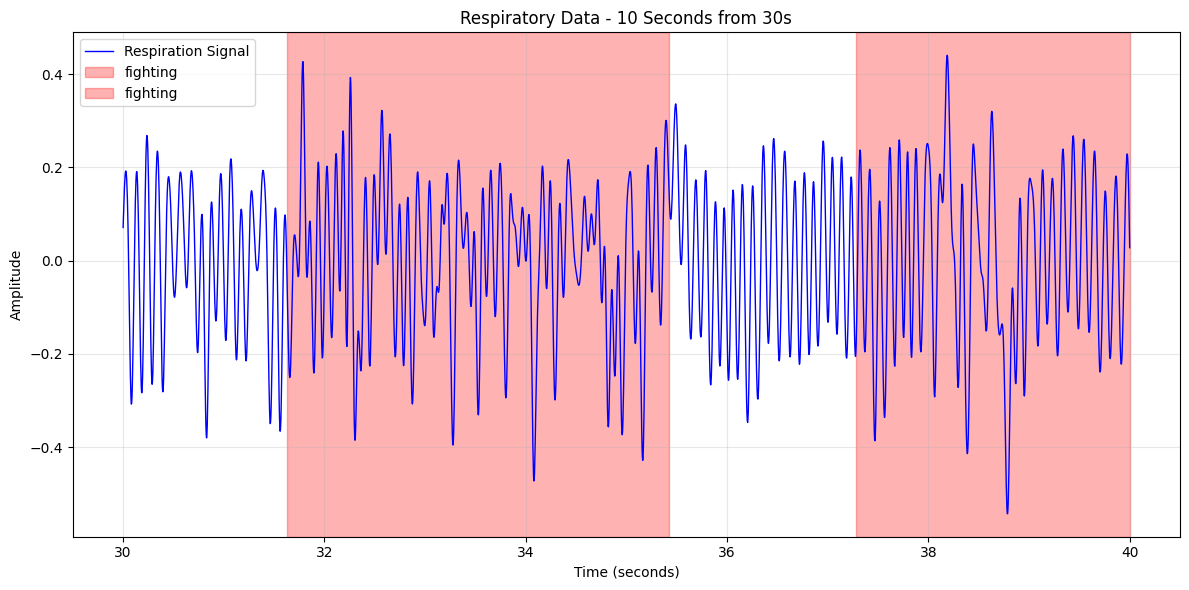

In [141]:
resp_plotting.resp_behavior_plot(resp_df, subj_11_b_resp_fs, start_time+30, duration=10)